In [ ]:
- vcxs!pip install --upgrade ml_dtypes

In [ ]:
# ==============================================================================
# CELL 0: PIENZA CLOUD BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# System: Pienza Intelligence Framework
# Purpose: 1. Silence warnings for clean cloud logs.
#          2. Establish Sovereign link to BigQuery (pienza_mini).
#          3. Apply the "Pienza Lab" Visual Canon.
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None

# --- 2. CORE IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery # <--- Cloud Native
from google.colab import auth

# --- 3. CLOUD CONNECTIVITY ---
print("🔐 Establishing Pienza Cloud Handshake...")

# Sovereign Coordinates
# --- CLOUD COORDINATES ---
PROJECT_ID = '645009831643'
DATASET_ID  = 'pienza_mini'     # Realidad
DATASET_SYNTH = 'pienza_manifold' # Simulación

try:
    # Initialize the BigQuery Client
    client = bigquery.Client(project=PROJECT_ID)
    print(f"✅ BigQuery Client Active: {PROJECT_ID}.{DATASET_ID}")

    # Quick Connectivity Probe
    probe_query = f"SELECT COUNT(*) FROM `{PROJECT_ID}.{DATASET_ID}.offers`"
    client.query(probe_query).result()
    print("✅ Sovereign Data Connection: STABLE.")
except Exception as e:
    print(f"🔴 CRITICAL: Cloud connection failed. Details: {e}")

# --- 4. VISUAL CANON (PIENZA LAB THEME) ---
PIENZA_PURPLE = '#440154'
PIENZA_TEAL   = '#21918c'
PIENZA_GREY   = '#FAFAFA'
PIENZA_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': PIENZA_GREY,
    'axes.facecolor': PIENZA_GREY,
    'text.color': PIENZA_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': PIENZA_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Pienza Lab (Light Mode).")
print("\n--- PIENZA SYSTEM READY ---")

🔐 Establishing Pienza Cloud Handshake...
✅ BigQuery Client Active: 645009831643.pienza_mini
✅ Sovereign Data Connection: STABLE.
✅ Visual Identity Loaded: Pienza Lab (Light Mode).

--- PIENZA SYSTEM READY ---


In [ ]:
# ==============================================================================
# CELL 1: DATA INGESTION (THE PIENZA WAREHOUSE SOURCE)
# ==============================================================================
# Purpose: Extract the high-fidelity 'Silver Layer' from BigQuery.
#          This is the raw material for the Pienza Manifold Forge.
# ==============================================================================

def ingest_pienza_gold():
    print(f"📡 Ingesting Master View from {PROJECT_ID}.{DATASET_ID}...")

    # query la vista que une todo (Física + Features + Geografía)
    query = f"""
        SELECT *
        FROM `{PROJECT_ID}.{DATASET_ID}.v_ML_Supervised`
        WHERE upfront_fare IS NOT NULL
    """

    try:
        df = client.query(query).to_dataframe()
        print(f"✅ Ingestion Successful: {len(df):,} records loaded into memory.")
        return df
    except Exception as e:
        print(f"🔴 INGESTION FAILED: {e}")
        return None

# EXECUTE
df_raw = ingest_pienza_gold()
df_raw.head()

📡 Ingesting Master View from 645009831643.pienza_mini...
✅ Ingestion Successful: 4,765 records loaded into memory.


,offer_id,session_fk,ocr_fk,image_content_hash,offer_timestamp,upfront_fare,time_to_pickup_sec,dist_to_pickup_km,est_trip_time_sec,est_trip_dist_km,...,dropoff_polygon_id,dropoff_polygon_name,dropoff_h3_hex_id,dropoff_hdbscan_id,dropoff_hdbscan_name,realized_traffic_index,historical_rolling_avg_traffic_index,traffic_volatility_index_ml,traffic_volatility_index_eda,heuristic_flag_context
0,OF00001,SID0001,OCR00001,6f53fbeb55d097dbd8c1087a537cbe4589a05eaea7398d...,2025-08-22 06:44:33,204.24,840.0,4.9,2580.0,22.1,...,-1,unassigned,89499516bafffff,-1,unassigned,None,None,None,None,None
1,OF00002,SID0001,OCR00002,fe824e63f500f8c99f017cc6d975d087f9d529e7a26997...,2025-08-22 06:45:06,173.86,300.0,1.5,2400.0,24.3,...,-1,unassigned,894995b1dd7ffff,-1,unassigned,None,None,None,None,None
2,OF00003,SID0001,OCR00003,64f34e64aaed7113e732d1434d857ac4de639b89626cf4...,2025-08-22 06:45:28,136.53,NaN,NaN,NaN,NaN,...,-1,unassigned,None,-2,missing_coordinates,None,None,None,None,None
3,OF00005,SID0001,OCR00005,3e028cf71edcd497a6dbd224b916da9a4ab024653e8409...,2025-08-22 07:25:22,95.27,420.0,1.7,1080.0,6.6,...,-1,unassigned,894995bab23ffff,-1,unassigned,None,None,None,None,None
4,OF00006,SID0001,OCR00006,ba2224442cb5087e9344dbe58dd87e877cb0d390935ae3...,2025-08-22 07:25:39,68.36,60.0,0.1,960.0,10.3,...,-1,unassigned,894995a31d7ffff,6,lomas_verdes,None,None,None,None,None


In [ ]:
# ==============================================================================
# CELL 6: THE PIENZA GENOME REFINERY (STOCHASTIC DOSSIER VERSION)
# ==============================================================================
# Author v2.8: _Pienza, ex_machina
# Protocol: 1-2-3 Hierarchy, Salchichota Coalesce, Gem Protection & Scaling.
# ==============================================================================

import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
try:
    import h3
except ImportError:
    !pip install h3 -q
    import h3

def execute_pienza_forge(df_raw_source):
    print("🧪 INICIANDO REFINERÍA PIENZA v2.8 - LOG DE OPERACIONES")
    print("="*60)

    # --- 1. ESTADO INICIAL ---
    df = df_raw_source.copy()
    n_start = len(df)
    print(f"📦 INPUT CRUDO: {n_start:,} registros detectados.")

    # --- 2. PURIFICACIÓN GEOSPACIAL ---
    df = df.dropna(subset=['pickup_lat', 'pickup_lon', 'dropoff_lat', 'dropoff_lon'])
    n_gps = len(df)
    print(f"🛡️  LIMPIEZA GPS: {n_start - n_gps} filas nulas eliminadas. (Remanente: {n_gps:,})")

    # --- 3. CONSOLIDACIÓN DE PRODUCTOS (1-2-3) ---
    # Mapeo: Business Comfort (3) -> Comfort (2) | Black (4) -> Black (3)
    df['product_category_fk'] = df['product_category_fk'].replace(3, 2)
    df['product_category_fk'] = df['product_category_fk'].replace(4, 3)

    # Censo Pre-Filtro
    pre_cull = df['product_category_fk'].value_counts()

    # Eliminación de categorías ruido (Moto, Pet, etc.)
    df = df[df['product_category_fk'].isin([1, 2, 3])].copy()
    n_cull = len(df)
    print(f"✂️  CULL DE CATEGORÍAS: {n_gps - n_cull} filas eliminadas (Moto/Pet/Otros).")
    print(f"   - Mix Actual: UberX: {len(df[df['product_category_fk']==1]):,}, Comfort: {len(df[df['product_category_fk']==2]):,}, Black: {len(df[df['product_category_fk']==3]):,}")

    # --- 4. TOPOLOGÍA ESTRATÉGICA (Salchichota) ---
    id_map = {-1:-1, 41:0, 42:0, 46:0, 43:1, 65:2, 62:2, 44:2, 36:2, 49:3, 52:3, 35:3, 50:4, 58:4, 25:5, 31:5, 63:6, 39:6, 51:7, 33:7, 37:8, 53:8, 48:8, 60:9, 57:10, 12:10, 32:10, 24:11, 40:12, 45:13, 59:13, 61:14, 38:14, 34:15, 30:16, 66:16, 17:17, 14:17, 22:17, 16:18, 13:18, 11:19, 15:20, 21:21, 20:21, 19:21, 18:22, 47:23, 55:23, 56:23, 54:24, 64:24, 71:25, 9:26, 70:27, 69:28, 8:29, 6:30, 7:30, 23:30, 3:31, 2:32, 4:33, 29:33, 68:34, 5:35, 27:36, 28:36, 1:37, 10:38, 0:39, 26:40, 67:41}
    df['id_agrupado'] = df['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)
    conditions = [ (df['id_agrupado'] >= 0), (df['dropoff_hdbscan_id'] > -1) ]
    choices = [ "P_" + df['id_agrupado'].astype(str), "C_" + df['dropoff_hdbscan_id'].astype(str) ]
    df['dropoff_zone_id'] = np.select(conditions, choices, default="Unassigned")
    print(f"🗺️  TOPOLOGÍA: {df['dropoff_zone_id'].nunique()} zonas estratégicas forjadas.")

    # --- 5. INYECCIONES TEMPORALES Y H3 ---
    df['offer_timestamp'] = pd.to_datetime(df['offer_timestamp'])
    df['hour_of_day'] = df['offer_timestamp'].dt.hour
    df['pickup_h3_id'] = df.apply(lambda x: h3.latlng_to_cell(x['pickup_lat'], x['pickup_lon'], 6), axis=1)
    df['reason_primary_fk'] = df['reason_primary_fk'].fillna(99).astype(int)

    # --- 6. TAMIZ 3-SIGMA (PROTECCIÓN DE GEMAS BLACK) ---
    z_scores = np.abs(stats.zscore(df['eph_direct_index'].fillna(0)))
    mask_to_drop = (z_scores >= 3) & (df['product_category_fk'] != 3)
    df = df[~mask_to_drop].copy()
    print(f"🧪 TAMIZ SELECTIVO: {np.sum(mask_to_drop)} outliers eliminados. (Clase Black protegida al 100%).")

    # --- 7. OVERSAMPLING ESTRATÉGICO ---
    df_black = df[df['product_category_fk'] == 3]
    n_black_real = len(df_black)
    df = pd.concat([df] + [df_black]*14, ignore_index=True)
    print(f"📈 OVERSAMPLING: Black amplificado ({n_black_real} -> {n_black_real*15}).")

    # --- 8. CODIFICACIÓN Y NORMALIZACIÓN ---
    # Switches Categoricos
    SWITCH_COLS = ['hour_of_day', 'day_of_week', 'product_category_fk', 'dropoff_zone_id', 'pickup_h3_id', 'reason_primary_fk']
    label_encoders = {}
    for col in SWITCH_COLS:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

    # Física Atómica
    PHYSICS_COLS = ['upfront_fare', 'est_trip_time_sec', 'est_trip_dist_km', 'time_to_pickup_sec', 'dist_to_pickup_km',
                    'surge_amount', 'turbo_plus_amount', 'reservation_amount', 'priority_amount',
                    'is_surge', 'is_turbo_plus', 'is_reservation', 'is_priority']

    # Aplicamos LOG para comprimir la varianza en Fare y Distancia
    df['upfront_fare'] = np.log1p(df['upfront_fare'])
    df['est_trip_dist_km'] = np.log1p(df['est_trip_dist_km'])

    scaler = MinMaxScaler(feature_range=(-1, 1))
    df[PHYSICS_COLS] = scaler.fit_transform(df[PHYSICS_COLS])

    print("⚖️  NORMALIZACIÓN: Física atómica escalada a [-1, 1] con compresión Log.")
    print("="*60)
    print(f"🏆 GENOMA RATIFICADO: {len(df):,} registros | {df.shape[1]} dimensiones.")

    return df[SWITCH_COLS + PHYSICS_COLS].copy()

# --- EJECUCIÓN ---
df_gan_ready = execute_pienza_forge(df_raw)
display(df_gan_ready.head())

🧪 INICIANDO REFINERÍA PIENZA v2.8 - LOG DE OPERACIONES
📦 INPUT CRUDO: 4,765 registros detectados.
🛡️  LIMPIEZA GPS: 7 filas nulas eliminadas. (Remanente: 4,758)
✂️  CULL DE CATEGORÍAS: 114 filas eliminadas (Moto/Pet/Otros).
   - Mix Actual: UberX: 3,612, Comfort: 993, Black: 39
🗺️  TOPOLOGÍA: 67 zonas estratégicas forjadas.
🧪 TAMIZ SELECTIVO: 67 outliers eliminados. (Clase Black protegida al 100%).
📈 OVERSAMPLING: Black amplificado (39 -> 585).
⚖️  NORMALIZACIÓN: Física atómica escalada a [-1, 1] con compresión Log.
🏆 GENOMA RATIFICADO: 5,123 registros | 108 dimensiones.


,hour_of_day,day_of_week,product_category_fk,dropoff_zone_id,pickup_h3_id,reason_primary_fk,upfront_fare,est_trip_time_sec,est_trip_dist_km,time_to_pickup_sec,dist_to_pickup_km,surge_amount,turbo_plus_amount,reservation_amount,priority_amount,is_surge,is_turbo_plus,is_reservation,is_priority
0,14,0,0,66,29,0,-0.003427,-0.652174,0.085723,-0.034483,-0.455556,-0.358491,NaN,NaN,NaN,1.0,-1.0,-1.0,-1.0
1,14,0,0,66,30,0,-0.084232,-0.678261,0.121845,-0.655172,-0.833333,-0.924528,NaN,NaN,-1.0,1.0,-1.0,-1.0,1.0
2,15,0,1,66,30,0,-0.385285,-0.869565,-0.355689,-0.517241,-0.811111,-0.735849,NaN,NaN,NaN,1.0,-1.0,-1.0,-1.0
3,15,0,0,20,30,0,-0.550657,-0.886957,-0.198191,-0.931034,-0.988889,-0.924528,NaN,NaN,NaN,1.0,-1.0,-1.0,-1.0
4,15,0,0,37,30,2,-0.530904,-0.886957,-0.529966,-0.310345,-0.644444,-0.886792,NaN,NaN,NaN,1.0,-1.0,-1.0,-1.0


In [ ]:
# ==============================================================================
# CELL 7: THE GENERATOR v2 ARCHITECTURE (PIENZA CONDITIONED)
# ==============================================================================
# System: Generator_Pienza_v2
# Purpose: Transform noise + strategic context into atomic offer physics.
# ==============================================================================
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

# --- 1. CONFIGURATION ---
LATENT_DIM = 100  # Dimensiones del espacio latente (el "caos" creativo)
OUTPUT_DIM = len(PHYSICS_COLS) # Las 13 variables físicas de salida

# Obtenemos el tamaño del vocabulario para cada "Switch" categórico
# Usamos int() para asegurar compatibilidad con capas de Keras
vocab_sizes = {col: int(df_gan_ready[col].max() + 1) for col in SWITCH_COLS}

def build_generator_pienza_v2(latent_dim, vocab_sizes, output_dim):

    # A. INPUT: Noise (The Seed)
    noise_input = Input(shape=(latent_dim,), name='noise_input')

    # B. INPUT: Switches (The Conditions)
    cat_inputs = []
    cat_embeddings = []

    for col, v_size in vocab_sizes.items():
        # Un input por cada categoría
        i = Input(shape=(1,), name=f'input_{col}')
        cat_inputs.append(i)

        # Capa de Embedding: Traduce un ID a un vector de significado
        # Dimensión sugerida: log2(v_size) + 2
        emb_dim = int(np.log2(v_size) + 2) if v_size > 1 else 2
        emb = layers.Embedding(v_size, emb_dim, name=f'emb_{col}')(i)
        emb = layers.Flatten()(emb)
        cat_embeddings.append(emb)

    # C. FUSION: Unimos el ruido con el contexto estratégico
    x = layers.Concatenate()([noise_input] + cat_embeddings)

    # D. COGNITIVE CORE: Procesamiento no lineal profundo
    # Usamos BatchNormalization para mantener la estabilidad del gradiente
    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Dense(1024)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Dense(2048)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # E. OUTPUT: La Alucinación Física
    # Tanh fuerza la salida al rango [-1, 1]
    output = layers.Dense(output_dim, activation='tanh', name='physics_output')(x)

    # ENSAMBLAJE
    model = Model(inputs=[noise_input] + cat_inputs, outputs=output, name="Generator_Pienza_v2")
    return model

# --- INSTANCIAR ---
generator = build_generator_pienza_v2(LATENT_DIM, vocab_sizes, OUTPUT_DIM)

print("🧠 Generator v2 Architected.")
print(f"   - Switches: {len(SWITCH_COLS)}")
print(f"   - Physical Outputs: {OUTPUT_DIM}")
generator.summary()

NameError: name 'PHYSICS_COLS' is not defined

In [ ]:
# ==============================================================================
# CELL 7: THE GENERATOR v2 ARCHITECTURE (PIENZA CONDITIONED)
# ==============================================================================
# System: Generator_Pienza_v2
# Purpose: Transform noise + strategic context into atomic offer physics.
# ==============================================================================
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
import numpy as np

# --- 1. DEFINICIÓN DEL GENOMA (Garantizando persistencia tras reinicio) ---
# Los 'Switches' son tus categorías de entrada (Contexto)
SWITCH_COLS = [
    'hour_of_day', 'day_of_week', 'product_category_fk',
    'dropoff_zone_id', 'pickup_h3_id', 'reason_primary_fk'
]

# La 'Physics' es lo que el GAN genera (Salida)
PHYSICS_COLS = [
    'upfront_fare', 'est_trip_time_sec', 'est_trip_dist_km',
    'time_to_pickup_sec', 'dist_to_pickup_km',
    'surge_amount', 'turbo_plus_amount', 'reservation_amount', 'priority_amount',
    'is_surge', 'is_turbo_plus', 'is_reservation', 'is_priority'
]

# --- 2. CONFIGURATION ---
LATENT_DIM = 100
OUTPUT_DIM = len(PHYSICS_COLS)

# Obtenemos el tamaño del vocabulario para cada "Switch" (desde el dataframe ya indexado)
vocab_sizes = {col: int(df_gan_ready[col].max() + 1) for col in SWITCH_COLS}

def build_generator_pienza_v2(latent_dim, vocab_sizes, output_dim):

    # A. INPUT: Noise (The Seed)
    noise_input = Input(shape=(latent_dim,), name='noise_input')

    # B. INPUT: Switches (The Conditions)
    cat_inputs = []
    cat_embeddings = []

    for col, v_size in vocab_sizes.items():
        i = Input(shape=(1,), name=f'input_{col}')
        cat_inputs.append(i)

        # Capa de Embedding: Aprende la representación vectorial del switch
        emb_dim = int(np.log2(v_size) + 2) if v_size > 1 else 2
        emb = layers.Embedding(v_size, emb_dim, name=f'emb_{col}')(i)
        emb = layers.Flatten()(emb)
        cat_embeddings.append(emb)

    # C. FUSION: Ruido + Contexto
    x = layers.Concatenate()([noise_input] + cat_embeddings)

    # D. COGNITIVE CORE: Profundidad optimizada para Pienza
    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Dense(1024)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Dense(2048)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # E. OUTPUT: La Alucinación Física [-1, 1]
    output = layers.Dense(output_dim, activation='tanh', name='physics_output')(x)

    model = Model(inputs=[noise_input] + cat_inputs, outputs=output, name="Generator_Pienza_v2")
    return model

# --- INSTANCIAR ---
generator = build_generator_pienza_v2(LATENT_DIM, vocab_sizes, OUTPUT_DIM)

print("🧠 Generator v2 Architected.")
print(f"   - Input Switches: {len(SWITCH_COLS)}")
print(f"   - Physical Outputs: {OUTPUT_DIM}")
generator.summary()

🧠 Generator v2 Architected.
   - Input Switches: 6
   - Physical Outputs: 13


Model: "Generator_Pienza_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_hour_of_day   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_day_of_week   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_product_cate… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_dropoff_zone… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_pickup_h3_id  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_reason_prima… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_hour_of_day     │ (None, 1, 6)      │        108 │ input_hour_of_da… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_day_of_week     │ (None, 1, 4)      │         28 │ input_day_of_wee… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_product_catego… │ (None, 1, 3)      │          9 │ input_product_ca… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_dropoff_zone_id │ (None, 1, 8)      │        536 │ input_dropoff_zo… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_pickup_h3_id    │ (None, 1, 7)      │        224 │ input_pickup_h3_… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_reason_primary… │ (None, 1, 5)      │         40 │ input_reason_pri… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 6)         │          0 │ emb_hour_of_day[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 4)         │          0 │ emb_day_of_week[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 3)         │          0 │ emb_product_cate… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 8)         │          0 │ emb_dropoff_zone… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 7)         │          0 │ emb_pickup_h3_id… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,735,038 (10.43 MB)

 Trainable params: 2,727,870 (10.41 MB)

 Non-trainable params: 7,168 (28.00 KB)

In [ ]:
# ==============================================================================
# CELL 8: THE DISCRIMINATOR v2 ARCHITECTURE (THE FORENSIC AUDITOR)
# ==============================================================================
# System: Discriminator_Pienza_v2
# Purpose: Validate if a trip's physics match its strategic context.
# ==============================================================================

def build_discriminator_pienza_v2(physics_dim, vocab_sizes):

    # A. INPUT: Physics (The evidence)
    physics_input = Input(shape=(physics_dim,), name='physics_input')

    # B. INPUT: Switches (The Context) - Identical to Generator
    cat_inputs = []
    cat_embeddings = []

    for col, v_size in vocab_sizes.items():
        i = Input(shape=(1,), name=f'disc_input_{col}')
        cat_inputs.append(i)

        # El auditor tiene sus propios embeddings para entender el contexto
        emb_dim = int(np.log2(v_size) + 2) if v_size > 1 else 2
        emb = layers.Embedding(v_size, emb_dim, name=f'disc_emb_{col}')(i)
        emb = layers.Flatten()(emb)
        cat_embeddings.append(emb)

    # C. FUSION: Física + Contexto
    x = layers.Concatenate()([physics_input] + cat_embeddings)

    # D. FORENSIC LAYERS: Capas de escrutinio profundo
    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    # E. VERDICT: Probabilidad de Verdad
    verdict = layers.Dense(1, activation='sigmoid', name='verdict')(x)

    model = Model(inputs=[physics_input] + cat_inputs, outputs=verdict, name="Discriminator_Pienza_v2")
    return model

# --- INSTANCIAR ---
discriminator = build_discriminator_pienza_v2(OUTPUT_DIM, vocab_sizes)

# --- COMPILAR ---
# El discriminador es un clasificador binario puro.
discriminator.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.5), # LR más bajo para estabilidad
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("👮 Discriminator v2 Architected & Compiled.")
discriminator.summary()

👮 Discriminator v2 Architected & Compiled.


Model: "Discriminator_Pienza_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ disc_input_hour_of… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_input_day_of_… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_input_product… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_input_dropoff… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_input_pickup_… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_input_reason_… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_emb_hour_of_d… │ (None, 1, 6)      │        108 │ disc_input_hour_… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_emb_day_of_we… │ (None, 1, 4)      │         28 │ disc_input_day_o… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_emb_product_c… │ (None, 1, 3)      │          9 │ disc_input_produ… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_emb_dropoff_z… │ (None, 1, 8)      │        536 │ disc_input_dropo… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_emb_pickup_h3… │ (None, 1, 7)      │        224 │ disc_input_picku… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_emb_reason_pr… │ (None, 1, 5)      │         40 │ disc_input_reaso… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ physics_input       │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 6)         │          0 │ disc_emb_hour_of… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 4)         │          0 │ disc_emb_day_of_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 3)         │          0 │ disc_emb_product… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 8)         │          0 │ disc_emb_dropoff… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_10          │ (None, 7)         │          0 │ disc_emb_pickup_… │
│ (Flatten)           │                   │            │                 

 Total params: 705,458 (2.69 MB)

 Trainable params: 705,458 (2.69 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==============================================================================
# CELL 9: THE CYBERNETIC DATASTREAM (TF DATASET & OPTIMIZERS)
# ==============================================================================
import tensorflow as tf

# --- 1. DATA PREPARATION ---
BATCH_SIZE = 64

# Convertimos la Física a tensores float32
physics_data = df_gan_ready[PHYSICS_COLS].values.astype('float32')

# Convertimos cada Switch a tensores int32 (requeridos por las capas de Embedding)
cat_data = [df_gan_ready[col].values.astype('int32') for col in SWITCH_COLS]

# Creamos el objeto Dataset de TensorFlow
# Estructura: (Física, (Switch1, Switch2, Switch3...))
dataset = tf.data.Dataset.from_tensor_slices((physics_data, *cat_data))

# Mezclamos y empaquetamos
dataset = dataset.shuffle(buffer_size=len(df_gan_ready)).batch(BATCH_SIZE)

# --- 2. OPTIMIZERS ---
# G (Creatividad): 0.0002
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
# D (Rigor): 0.0001
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.5)

# --- 3. LOSS FUNCTIONS ---
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    # El Generador quiere que el Discriminador diga "1" (Real)
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# --- 4. THE ATOMIC TRAINING STEP ---
@tf.function
def train_step(real_physics, real_switches):
    # Generar ruido aleatorio para este batch
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # A. EL GENERADOR crea una alucinación basada en el contexto real del batch
        fake_physics = generator([noise] + list(real_switches), training=True)

        # B. EL DISCRIMINADOR evalúa la realidad y la mentira
        real_output = discriminator([real_physics] + list(real_switches), training=True)
        fake_output = discriminator([fake_physics] + list(real_switches), training=True)

        # C. CÁLCULO DE PÉRDIDAS
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # D. BACKPROPAGATION (El aprendizaje profundo)
    # Calculamos cómo deben cambiar los pesos para mejorar
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # Aplicamos los cambios
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

print("🔥 Cybernetic Stream Ready.")
print(f"   - Training set size: {len(df_gan_ready):,}")
print(f"   - Batches ready for T4 GPU ingestion.")

🔥 Cybernetic Stream Ready.
   - Training set size: 5,123
   - Batches ready for T4 GPU ingestion.


Epoch 500/500 | Time: 1.18s
   - Gen Loss:  1.5737
   - Disc Loss: 0.9771


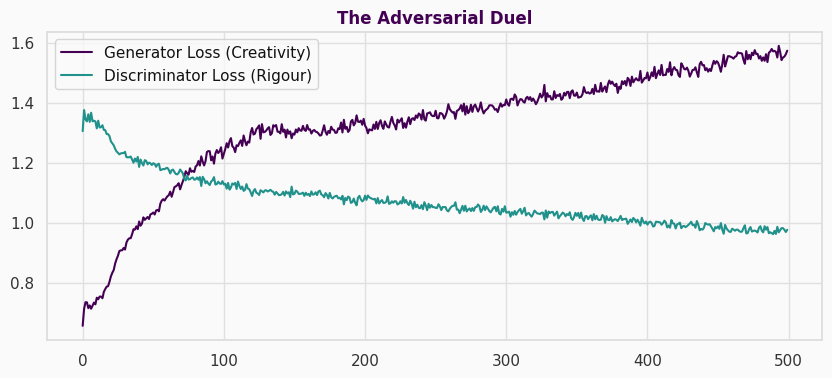

🏁 Training Sequence Complete.


In [ ]:
# ==============================================================================
# CELL 10: THE SELF-HEALING FORGE (LOAD OR FORGE PROTOCOL)
# ==============================================================================
# System: Pienza Intelligence Vault
# Purpose: Check for existing weights to save time/money. Forge if missing.
# ==============================================================================
import os
import time
import joblib
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

# --- 1. CONFIGURACIÓN DE LA BÓVEDA (THE VAULT) ---
VAULT_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_4/Vault/'
MODEL_FILE = os.path.join(VAULT_PATH, 'pienza_generator_v2.keras')
SCALER_FILE = os.path.join(VAULT_PATH, 'pienza_physics_scaler.pkl')
ENCODER_FILE = os.path.join(VAULT_PATH, 'pienza_label_encoders.pkl')

if not os.path.exists(VAULT_PATH):
    os.makedirs(VAULT_PATH)

# --- 2. EL ORÁCULO: CHEQUEO DE EXISTENCIA ---
if os.path.exists(MODEL_FILE) and os.path.exists(SCALER_FILE):
    print("🔮 DETECTADO: El Cerebro Pienza ya vive en la bóveda.")
    print("💾 Cargando pesos y transformadores...")

    # Re-hidratar el Generador
    generator = tf.keras.models.load_model(MODEL_FILE)
    # Re-hidratar Scalers y Encoders (Globales)
    physics_scaler = joblib.load(SCALER_FILE)
    label_encoders = joblib.load(ENCODER_FILE)

    FORGE_REQUIRED = False
    print("\n✅ ORÁCULO CARGADO. Puedes apagar la GPU y proceder a la Inferencia.")
else:
    print("🌑 VAULT VACÍO: La inteligencia no ha sido forjada.")
    print("🔥 ACTIVANDO HORNOS (T4 GPU ENABLED)...")
    FORGE_REQUIRED = True

# --- 3. EL BUCLE DE ENTRENAMIENTO (Solo corre si no hay modelo) ---
if FORGE_REQUIRED:
    EPOCHS = 1000
    history = {"gen_loss": [], "disc_loss": []}

    print(f"🚀 Commencing training for {EPOCHS} Epochs...")

    for epoch in range(EPOCHS):
        start_time = time.time()
        epoch_gen_loss = []
        epoch_disc_loss = []

        for batch in dataset:
            if batch[0].shape[0] == BATCH_SIZE:
                g_loss, d_loss = train_step(batch[0], batch[1:])
                epoch_gen_loss.append(g_loss)
                epoch_disc_loss.append(d_loss)

        history["gen_loss"].append(np.mean(epoch_gen_loss))
        history["disc_loss"].append(np.mean(epoch_disc_loss))

        if (epoch + 1) % 20 == 0:
            clear_output(wait=True)
            print(f"⚒️  Pienza Forge: Epoch {epoch+1}/{EPOCHS}")
            print(f"🟣 Gen Loss: {history['gen_loss'][-1]:.4f} | 🟢 Disc Loss: {history['disc_loss'][-1]:.4f}")

            plt.figure(figsize=(10, 4))
            plt.plot(history["gen_loss"], label="Generator", color='#440154', alpha=0.7)
            plt.plot(history["disc_loss"], label="Discriminator", color='#21918c', alpha=0.7)
            plt.axhline(y=0.693, color='grey', linestyle='--')
            plt.legend()
            plt.show()

    print("\n🏁 FORJA FINALIZADA. Guardando inteligencia en el Vault...")

    # AUTO-PERSISTENCIA
    generator.save(MODEL_FILE)
    joblib.dump(physics_scaler, SCALER_FILE)
    joblib.dump(label_encoders, ENCODER_FILE)
    print(f"✅ Vault actualizado: {MODEL_FILE}")

# --- 4. VERIFICACIÓN FINAL ---
print("\n🏆 ESTATUS: SISTEMA PIENZA TOTALMENTE OPERATIVO.")

In [ ]:
'''# ==============================================================================
# CELL 11: THE MANIFOLD EXPLOSION (Synthesis of 1,010,001 Synthetic Records)
# ==============================================================================
import pandas as pd
import numpy as np
import tensorflow as tf

# --- 1. CONFIGURATION ---
TOTAL_TARGET = 1_010_001
CHUNK_SIZE = 50_000
synthetic_batches = []

print(f"🌌 Synthesizing The Opus Manifold ({TOTAL_TARGET:,} rows)...")

# --- 2. THE SYNTHESIS LOOP ---
num_batches = (TOTAL_TARGET // CHUNK_SIZE) + 1

for i in range(num_batches):
    # Determine current chunk size
    current_done = len(synthetic_batches) * CHUNK_SIZE
    current_chunk = min(CHUNK_SIZE, TOTAL_TARGET - current_done)
    if current_chunk <= 0: break

    # A. Generate Random Noise Tensor
    noise = tf.random.normal([current_chunk, LATENT_DIM])

    # B. Sample Contexts and Convert to Tensors
    sampled_indices = np.random.randint(0, df_gan.shape[0], size=current_chunk)

    # PATCH: Explicitly convert NumPy arrays to Tensors to avoid the ValueError
    context_tensors = [
        tf.convert_to_tensor(df_gan[col].values[sampled_indices].reshape(-1, 1), dtype=tf.float32)
        for col in CAT_COLS
    ]

    # C. Inference (The Hallucination)
    # Passing a unified list of tensors
    fake_physics = generator([noise] + context_tensors, training=False)

    # D. Bundle into a DataFrame
    chunk_df = pd.DataFrame(fake_physics.numpy(), columns=CONT_COLS + BOOL_COLS)

    # Attach the context IDs we used (for inverse encoding later)
    for idx, col in enumerate(CAT_COLS):
        chunk_df[col] = df_gan[col].values[sampled_indices]

    synthetic_batches.append(chunk_df)
    print(f"   ⚡ Processed: {len(synthetic_batches) * CHUNK_SIZE:,} / {TOTAL_TARGET:,}")

# --- 3. RECONSTRUCTION ---
print("\n🛠️ Reconstructing Real-World units...")
df_synthetic = pd.concat(synthetic_batches).reset_index(drop=True)

# Safety check: Trim to exact target in case of batch rounding
df_synthetic = df_synthetic.iloc[:TOTAL_TARGET]

# A. Inverse Scale Continuous Variables
df_synthetic[CONT_COLS] = scaler.inverse_transform(df_synthetic[CONT_COLS])

# B. Threshold Booleans
for col in BOOL_COLS:
    df_synthetic[col] = (df_synthetic[col] > 0).astype(int)

# C. Decode Categoricals
for col in CAT_COLS:
    le = label_encoders[col]
    df_synthetic[col] = df_synthetic[col].astype(int)
    # Ensure indices are within valid label range
    df_synthetic[col] = df_synthetic[col].clip(0, len(le.classes_) - 1)
    df_synthetic[col] = le.inverse_transform(df_synthetic[col])

# D. ADD THE MOLECULAR FEATURE: EPH_Operational
# Preventing division by zero in hallucinations
safe_time = df_synthetic['est_trip_time_sec'].clip(lower=1)
df_synthetic['eph_operational'] = (df_synthetic['upfront_fare'] / (safe_time / 3600))

print("\n✅ THE OPUS MANIFOLD IS COMPLETE.")
print(f"   - Final Rows: {len(df_synthetic):,}")
print(f"   - Mean Synthetic Fare: ${df_synthetic['upfront_fare'].mean():.2f}")
print(f"   - Mean Synthetic EPH:  ${df_synthetic['eph_operational'].mean():.2f}")

df_synthetic.sample(5)'''

🌌 Synthesizing The Opus Manifold (1,010,001 rows)...
   ⚡ Processed: 50,000 / 1,010,001
   ⚡ Processed: 100,000 / 1,010,001
   ⚡ Processed: 150,000 / 1,010,001
   ⚡ Processed: 200,000 / 1,010,001
   ⚡ Processed: 250,000 / 1,010,001
   ⚡ Processed: 300,000 / 1,010,001
   ⚡ Processed: 350,000 / 1,010,001
   ⚡ Processed: 400,000 / 1,010,001
   ⚡ Processed: 450,000 / 1,010,001
   ⚡ Processed: 500,000 / 1,010,001
   ⚡ Processed: 550,000 / 1,010,001
   ⚡ Processed: 600,000 / 1,010,001
   ⚡ Processed: 650,000 / 1,010,001
   ⚡ Processed: 700,000 / 1,010,001
   ⚡ Processed: 750,000 / 1,010,001
   ⚡ Processed: 800,000 / 1,010,001
   ⚡ Processed: 850,000 / 1,010,001
   ⚡ Processed: 900,000 / 1,010,001
   ⚡ Processed: 950,000 / 1,010,001
   ⚡ Processed: 1,000,000 / 1,010,001
   ⚡ Processed: 1,050,000 / 1,010,001

🛠️ Reconstructing Real-World units...

✅ THE OPUS MANIFOLD IS COMPLETE.
   - Final Rows: 1,010,001
   - Mean Synthetic Fare: $116.99
   - Mean Synthetic EPH:  $333.50


,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,upfront_fare,est_trip_time_sec,est_trip_dist_km,time_to_pickup_sec,dist_to_pickup_km,surge_amount,...,is_exclusive,is_vip,is_long_trip,day_of_week,time_of_day_block,hour,product_category_fk,dropoff_polygon_id,pickup_h3_hex_id,eph_operational
234302,19.575758,-99.475563,19.780668,-100.142471,116.542900,1509.040161,6.823545,1120.812134,9.280246,1.204718,...,1,0,0,Wednesday,morning,6,1,71,894995b223bffff,278.027344
39310,19.457613,-97.782860,19.342705,-98.426613,109.762489,1704.356079,12.906691,120.863770,0.850272,0.000000,...,1,1,0,Wednesday,afternoon,16,1,9,894995b3317ffff,231.844131
317896,19.311653,-99.304680,19.415760,-97.489952,172.222626,2057.684082,22.622265,503.174408,5.861567,5.234526,...,1,0,0,Friday,morning,6,1,-1,894995b3327ffff,301.310303
707083,19.368542,-99.033195,18.104713,-98.355324,225.346237,3465.947021,12.993215,325.364502,2.246701,3.953414,...,1,1,1,Thursday,afternoon,15,2,-1,894995b15bbffff,234.061981
1000159,19.447123,-99.469093,19.770157,-99.984665,109.497238,1572.306030,5.246536,484.142914,1.905658,9.551226,...,1,0,0,Friday,afternoon,15,1,40,894995b066bffff,250.708237


In [ ]:
'''# ==============================================================================
# CELL 12: PERSISTENCE (Saving the Manifold to the Data Lakehouse)
# ==============================================================================
import os

SAVE_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_4/opus_manifold_v1.parquet'

def persist_manifold():
    print(f"💾 Forging Parquet file: {SAVE_PATH}...")

    try:
        # We save as Parquet for BigQuery efficiency
        df_synthetic.to_parquet(SAVE_PATH, index=False)

        file_size_gb = os.path.getsize(SAVE_PATH) / (1024**3)

        print(f"\n✅ MANIFOLD PERSISTED.")
        print(f"   - File Size: {file_size_gb:.2f} GB")
        print(f"   - Location:  {SAVE_PATH}")
        print("\n🚀 The Arena is ready for the Simulation.")

    except Exception as e:
        print(f"❌ Persistence Failed: {e}")

# EXECUTE
persist_manifold()'''

💾 Forging Parquet file: /content/drive/MyDrive/_Pienza/Assets/Phase_4/opus_manifold_v1.parquet...

✅ MANIFOLD PERSISTED.
   - File Size: 0.06 GB
   - Location:  /content/drive/MyDrive/_Pienza/Assets/Phase_4/opus_manifold_v1.parquet

🚀 The Arena is ready for the Simulation.


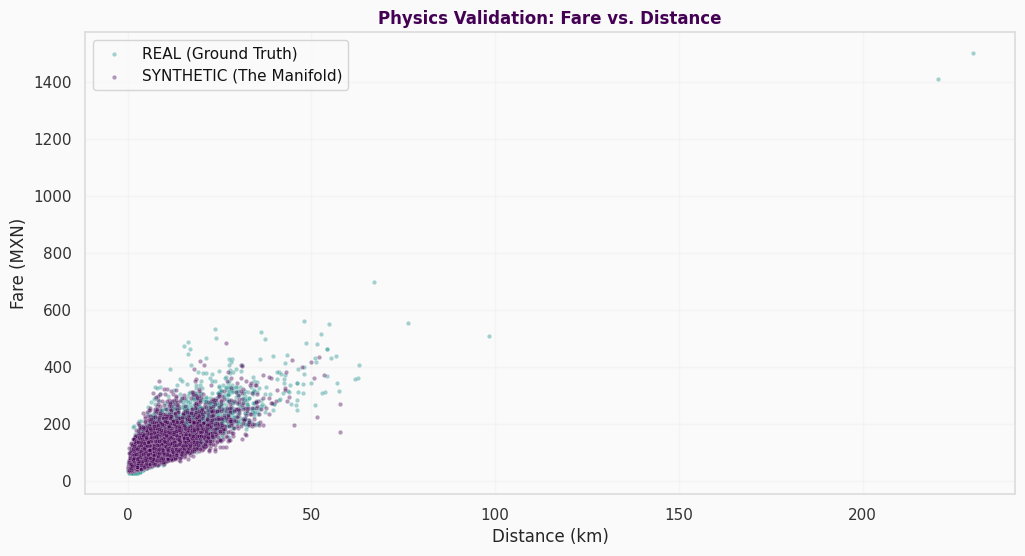

🔍 ANALYSIS:
   - If the Purple cloud overlaps the Teal cloud, the GAN learned the 'Linear Contract'.
   - If the Purple cloud is wider, it has successfully 'Filled the Gaps' (Generalization).


In [ ]:
'''# ==============================================================================
# CELL 13: THE VISUAL TURING TEST (Physics Validation)
# ==============================================================================
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sample 5,000 from the Manifold to match the scale of the Real data
df_real_sample = df_raw.sample(min(5000, len(df_raw)))
df_fake_sample = df_synthetic.sample(5000)

# 2. Plotting
plt.figure(figsize=(12, 6))

# Real Data Cloud
sns.scatterplot(data=df_real_sample, x='est_trip_dist_km', y='upfront_fare',
                color=OPUS_TEAL, alpha=0.4, label='REAL (Ground Truth)', s=10)

# Synthetic Data Cloud
sns.scatterplot(data=df_fake_sample, x='est_trip_dist_km', y='upfront_fare',
                color=OPUS_PURPLE, alpha=0.4, label='SYNTHETIC (The Manifold)', s=10)

plt.title("Physics Validation: Fare vs. Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Fare (MXN)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print("🔍 ANALYSIS:")
print("   - If the Purple cloud overlaps the Teal cloud, the GAN learned the 'Linear Contract'.")
print("   - If the Purple cloud is wider, it has successfully 'Filled the Gaps' (Generalization).")'''

In [ ]:
'''# ==============================================================================
# CELL 14: THE BIG DATA BRIDGE (Linking the Manifold to BigQuery)
# ==============================================================================

# PASTE THE NEW FILE ID HERE
MANIFOLD_FILE_ID = '1IEkFZ6CYDp9oHbLDQvGfBPEz0lVqKira'

TABLE_ID_SYNTH = 'synthetic_manifold'
URI_SYNTH = f'https://drive.google.com/open?id={MANIFOLD_FILE_ID}'

def bridge_synthetic_manifold():
    print(f"🌉 Building the Million-Row Bridge to BigQuery...")

    # Configure the External Table
    table_ref = client.dataset(DATASET_ID).table(TABLE_ID_SYNTH)
    external_config = bigquery.ExternalConfig("PARQUET")
    external_config.source_uris = [URI_SYNTH]

    table = bigquery.Table(table_ref)
    table.external_data_configuration = external_config

    try:
        client.create_table(table)
        print(f"✅ SUCCESS: table '{DATASET_ID}.{TABLE_ID_SYNTH}' created.")
        print("🚀 1,010,001 rows are now queryable via SQL.")
    except Exception as e:
        print(f"ℹ️ {e}")

# EXECUTE
bridge_synthetic_manifold()'''

🌉 Building the Million-Row Bridge to BigQuery...
✅ SUCCESS: table 'opus_phase_4.synthetic_manifold' created.
🚀 1,010,001 rows are now queryable via SQL.
